# Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind



# Data Loading

In [ ]:
df = pd.read_csv("/content/orders.csv")
df.head()

,order_id,customer_id,order_date,year,month,quarter,day_of_week,product_name,category,unit_price_usd,...,payment_method,device_used,delivery_days,delivery_date,order_status,returned,customer_rating,session_duration_minutes,pages_viewed_before_purchase,is_repeat_customer
0,O000001,C07108,2020-08-27,2020,8,Q3,Thursday,Tire Inflator,Automotive,62.91,...,Credit Card,Desktop,3,2020-08-30,Delivered,0,NaN,14.4,1,1
1,O000002,C03487,2024-04-11,2024,4,Q2,Thursday,Stud Earrings Gold,Jewelry & Accessories,18.44,...,Credit Card,Mobile,2,2024-04-13,Delivered,0,NaN,9.0,4,0
2,O000003,C03062,2023-06-25,2023,6,Q2,Sunday,Pen Set Premium,Office Supplies,109.79,...,PayPal,Desktop,3,2023-06-28,Delivered,0,4.0,3.2,17,0
3,O000004,C00888,2020-08-16,2020,8,Q3,Sunday,Smart Watch Series 5,Electronics,87.21,...,Credit Card,Tablet,2,2020-08-18,Returned,1,NaN,32.2,3,1
4,O000005,C01674,2020-04-24,2020,4,Q2,Friday,Stud Earrings Gold,Jewelry & Accessories,94.30,...,Debit Card,Mobile,5,2020-04-29,Delivered,0,2.8,54.7,2,1


In [ ]:

df.shape

(25000, 28)

# Database Compatibility


Check type, column, and content of data, followed by format cleaning. Then, evaluate whether the dataset is suitable for retention analysis.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   order_id                      25000 non-null  object 
 1   customer_id                   25000 non-null  object 
 2   order_date                    25000 non-null  object 
 3   year                          25000 non-null  int64  
 4   month                         25000 non-null  int64  
 5   quarter                       25000 non-null  object 
 6   day_of_week                   25000 non-null  object 
 7   product_name                  25000 non-null  object 
 8   category                      25000 non-null  object 
 9   unit_price_usd                25000 non-null  float64
 10  quantity                      25000 non-null  int64  
 11  subtotal_usd                  25000 non-null  float64
 12  discount_pct                  25000 non-null  int64  
 13  d

In [ ]:
import pandas as pd

df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["delivery_date"] = pd.to_datetime(df["delivery_date"], errors="coerce")

In [ ]:
df.describe()

,order_date,year,month,unit_price_usd,quantity,subtotal_usd,discount_pct,discount_amount_usd,shipping_fee_usd,tax_pct,tax_amount_usd,total_amount_usd,delivery_days,delivery_date,returned,customer_rating,session_duration_minutes,pages_viewed_before_purchase,is_repeat_customer
count,25000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000,25000.000000,9251.000000,25000.000000,25000.00000,25000.000000
mean,2023-02-20 09:53:58.271999744,2022.652840,6.352280,68.124030,1.695520,116.187322,5.630000,6.345500,3.867579,10.677080,11.746785,125.456186,4.179480,2023-02-24 14:12:25.344000256,0.080800,4.002324,16.780432,6.51256,0.645960
min,2020-01-01 00:00:00,2020.000000,1.000000,3.360000,1.000000,3.360000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,1.000000,2020-01-03 00:00:00,0.000000,1.500000,0.300000,1.00000,0.000000
25%,2021-07-30 18:00:00,2021.000000,3.000000,29.250000,1.000000,38.467500,0.000000,0.000000,0.000000,8.000000,2.300000,43.450000,3.000000,2021-08-03 00:00:00,0.000000,3.600000,7.100000,2.00000,0.000000
50%,2023-02-17 00:00:00,2023.000000,6.000000,51.530000,1.000000,72.390000,0.000000,0.000000,3.990000,10.000000,6.220000,78.775000,4.000000,2023-02-22 00:00:00,0.000000,4.100000,12.100000,5.00000,1.000000
75%,2024-09-17 00:00:00,2024.000000,9.000000,87.877500,2.000000,140.160000,10.000000,5.250000,6.990000,18.000000,13.990000,149.872500,5.000000,2024-09-21 00:00:00,0.000000,4.400000,21.100000,9.00000,1.000000
max,2026-03-30 00:00:00,2026.000000,12.000000,697.030000,5.000000,2636.450000,50.000000,421.580000,9.990000,20.000000,303.990000,2730.880000,14.000000,2026-04-12 00:00:00,1.000000,5.000000,361.200000,24.00000,1.000000
std,NaN,1.814996,3.514614,57.258933,1.045436,136.994998,9.740785,17.530764,3.269618,6.504922,17.723056,145.635016,2.548507,NaN,0.272533,0.577576,15.811830,5.26557,0.478231


Data types are compatible with retention analysis.

In [ ]:
customer_freq = df.groupby("customer_id")["order_id"].count()
customer_freq.describe()

,order_id
count,7663.000000
mean,3.262430
std,1.670653
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,12.000000


In [ ]:
customer_freq.value_counts().sort_index()

,count
order_id,
1,1093
2,1757
3,1769
4,1396
5,871
6,469
7,186
8,86
9,23


Frequency of order per customer at 3.26 with reasonable distribution.

### Conclusion: The dataset is suitable for retention analysis

# Data Processing

Check the null-valued rows.

In [ ]:
df.isna().any(axis = 1).sum()

np.int64(15749)

Investigate the rows.

In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
customer_rating,15749
order_id,0
order_date,0
customer_id,0
month,0
quarter,0
day_of_week,0
product_name,0
category,0
unit_price_usd,0


Drop the column "customer_rating" for cleaning null values.

In [ ]:
df = df.drop(columns="customer_rating")

Recheck

In [ ]:
df.isna().any(axis = 1).sum()

np.int64(0)

Check duplicated rows.

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
order_id,object
customer_id,object
order_date,datetime64[ns]
year,int64
month,int64
quarter,object
day_of_week,object
product_name,object
category,object
unit_price_usd,float64


# Exploratory Data Analysis (EDA)

## Cohort Analysis

Cohort analysis allows businesses to compare the behavior of different customer groups (cohorts) over time. This method focuses on the behavior of specific groups rather than looking at the customer base as a whole

First, check repeat_rate.

In [ ]:
total_customer = df["customer_id"].nunique()
repeatedCustomer = (customer_freq).sum()
repeat_rate = repeatedCustomer/total_customer

print(repeat_rate)

3.2624298577580584


Create the cohort table grouped by cohort month and aggregated by customer amount, quantity, and revenue.

In [ ]:
cohort = df.copy()

cohort["order_date"] = pd.to_datetime(cohort["order_date"])
cohort["order_month"] = cohort["order_date"].dt.to_period("M")

cohort["cohort_month"] = cohort.groupby("customer_id")["order_month"].transform("min")

cohort["cohort_index"] = ((cohort["order_month"].dt.year-cohort["cohort_month"].dt.year)*12
                          +(cohort["order_month"].dt.month - cohort["cohort_month"].dt.month
                            +1))

cohort = cohort[[
    "order_id",
    "customer_id",
    "quantity",
    "total_amount_usd",
    "order_month",
    "cohort_month",
    "cohort_index"
]]

cohort.head()


,order_id,customer_id,quantity,total_amount_usd,order_month,cohort_month,cohort_index
0,O000001,C07108,1,74.23,2020-08,2020-04,5
1,O000002,C03487,1,24.27,2024-04,2021-04,37
2,O000003,C03062,1,94.86,2023-06,2023-06,1
3,O000004,C00888,1,47.10,2020-08,2020-08,1
4,O000005,C01674,2,208.02,2020-04,2020-04,1


In [ ]:
cohort_data = cohort.groupby(["cohort_month", "cohort_index"]).agg(
    customers=('customer_id', 'nunique'),
    quantity=('quantity', 'sum'),
    total_amount_usd=('total_amount_usd', 'sum')
)

cohort_data.head()

customers  quantity  total_amount_usd
cohort_month cohort_index                                       
2020-01      1                   315       552          41113.87
             2                    11        21           1229.29
             3                    17        31           2904.33
             4                    10        13            780.87
             5                     9        18           1512.69

In [ ]:
cohort_matix = cohort_data.reset_index().pivot_table(
    index="cohort_month",
    columns="cohort_index",
    values=["customers", "quantity", "total_amount_usd"]
)

cohort_matix.head()

customers                                                        \
cohort_index        1     2     3     4     5     6     7     8     9     10   
cohort_month                                                                   
2020-01          315.0  11.0  17.0  10.0   9.0  12.0  16.0   8.0  14.0  11.0   
2020-02          301.0  18.0   7.0  12.0  10.0  12.0  16.0  15.0  12.0  16.0   
2020-03          276.0   7.0  21.0   8.0  12.0  20.0   5.0  14.0   9.0  10.0   
2020-04          304.0  19.0  16.0  10.0  18.0   8.0  14.0  13.0  20.0  15.0   
2020-05          289.0  13.0  12.0  15.0  11.0  15.0  10.0  15.0  17.0   6.0   

              ... total_amount_usd                                      \
cohort_index  ...               66       67       68       69       70   
cohort_month  ...                                                        
2020-01       ...          2093.20  2864.45  1508.49   831.61   608.18   
2020-02       ...          1582.28  2750.17   299.33  1075.93  1068.63   
2020-03       ...          1348.20  2013.32  2148.47  2375.52  2382.97   
2020-04       ...           656.13  1777.68   718.00  1346.20  1018.26   
2020-05       ...           822.11  2566.31  2004.16  2095.82   892.12   

                                                           
cohort_index       71       72       73       74       75  
cohort_month                                               
2020-01       1309.63  1542.27  1917.75  2857.72  1247.92  
2020-02       2069.74  1201.74   649.99  1365.06      NaN  
2020-03       1547.91  2052.94  1813.90      NaN      NaN  
2020-04       1115.68  1540.16      NaN      NaN      NaN  
2020-05        503.06      NaN      NaN      NaN      NaN  

[5 rows x 225 columns]

Create cohort matrices based on customer amount, quantity, and revenue.




In [ ]:
revenue_matrix = cohort_data.reset_index().pivot(
    index="cohort_month",
    columns="cohort_index",
    values="total_amount_usd")

quantity_matrix = cohort_data.reset_index().pivot(
    index="cohort_month",
    columns="cohort_index",
    values="quantity"
)

customer_matrix = cohort_data.reset_index().pivot(
    index="cohort_month",
    columns="cohort_index",
    values="customers"
)

In [ ]:
retention_rate = customer_matrix.div(customer_matrix[1], axis=0)

revenue_rate = revenue_matrix.div(revenue_matrix[1], axis=0)
quantity_rate = quantity_matrix.div(quantity_matrix[1], axis=0)

Show the cohort tables.

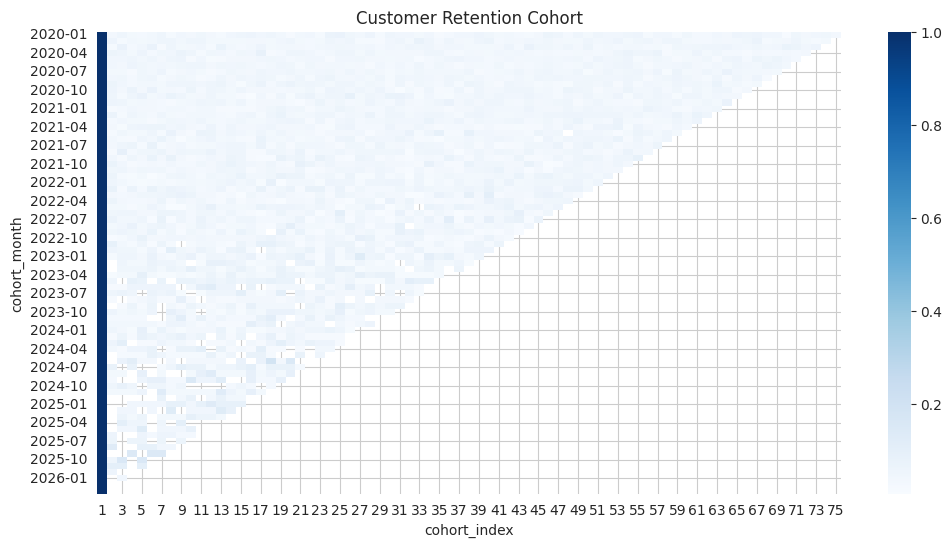

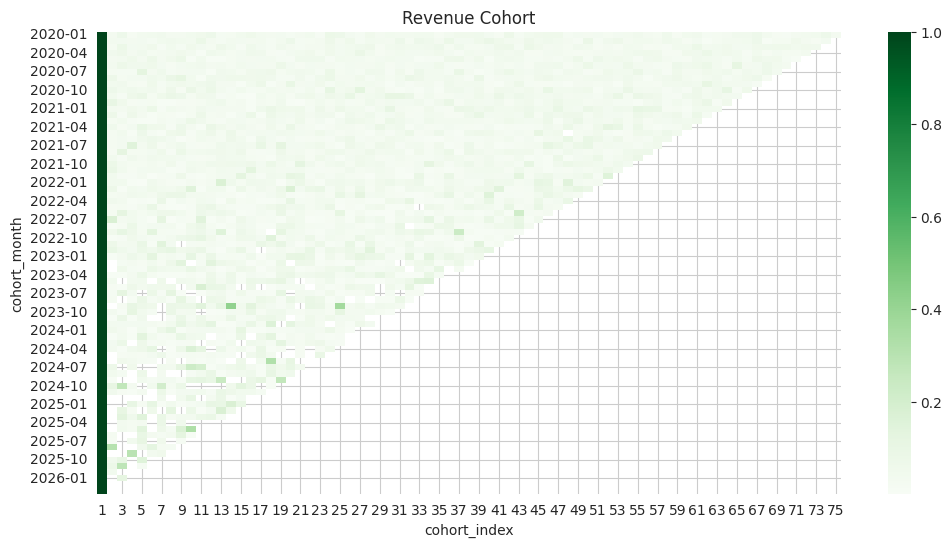

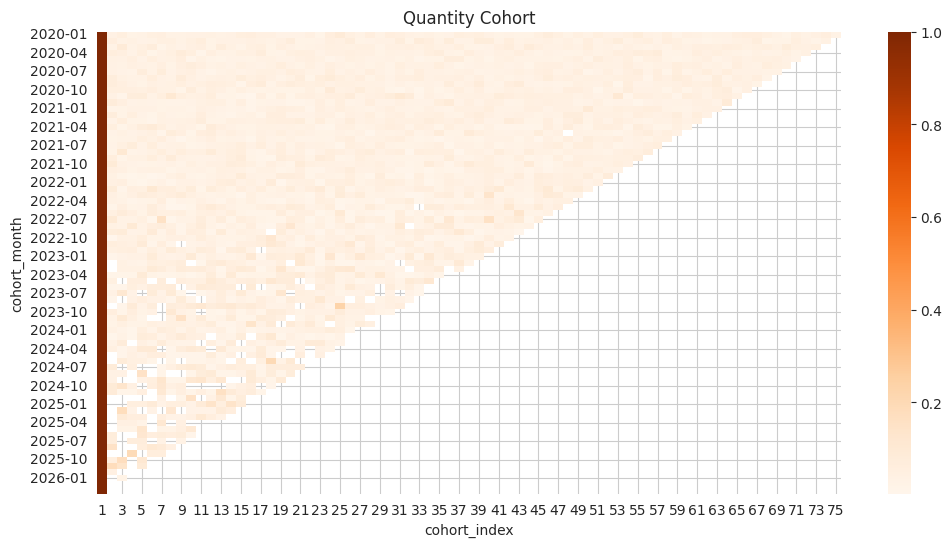

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(retention_rate, cmap="Blues")
plt.title("Customer Retention Cohort")
plt.show()

plt.figure(figsize=(12,6))
sns.heatmap(revenue_rate, cmap="Greens")
plt.title("Revenue Cohort")
plt.show()

plt.figure(figsize=(12,6))
sns.heatmap(quantity_rate, cmap="Oranges")
plt.title("Quantity Cohort")
plt.show()

Calculate important cohort KPIs: cohort size, cohort lifetime, early drop rate, final retention rate, decay speed, LTV Proxy, total per cohort.

In [ ]:
cohort_lifetime = retention_rate.sum(axis=1)

final_retention = retention_rate.replace([np.inf, np.nan], 0).iloc[:, -1]

early_drop = ((customer_matrix[1] - customer_matrix[2]) / customer_matrix[1]).replace([np.inf, np.nan], 0)

decay_speed = retention_rate.diff(axis=1).mean(axis=1)

ltv_proxy = (revenue_matrix.sum(axis=1) / customer_matrix[1]).replace([np.inf, np.nan], 0)

cohort_summary = pd.DataFrame({
    "cohort_size": customer_matrix[1],
    "lifetime": cohort_lifetime,
    "early_drop": early_drop,
    "final_retention": final_retention,
    "decay_speed": decay_speed,
    "ltv_proxy": ltv_proxy,
    "total_revenue": revenue_matrix.sum(axis=1)
})

cohort_summary.sort_values("total_revenue", ascending=False).head()

,cohort_size,lifetime,early_drop,final_retention,decay_speed,ltv_proxy,total_revenue
cohort_month,,,,,,,
2020-01,315.0,4.041270,0.965079,0.034921,-0.013042,517.082794,162881.08
2020-02,301.0,3.973422,0.940199,0.000000,-0.013289,512.123588,154149.20
2020-03,276.0,4.097826,0.974638,0.000000,-0.013084,546.926413,150951.69
2020-04,304.0,3.861842,0.937500,0.000000,-0.013575,490.865559,149223.13
2020-05,289.0,3.782007,0.955017,0.000000,-0.013890,498.401730,144038.10


## RFM

RFM is a method used for analyzing customer value and segmenting customers, which is commonly used in database marketing and direct marketing. It is based on 3 customer KPIs:
- Recency = How recently did the customer purchase?
- Frequency = How often do they purchase?
- Monetary Value = How much do they spend?

Create RFM table.

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])

snapshot_date = df['order_date'].max()

rfm = df.groupby("customer_id").agg({

    "order_date": lambda x: (snapshot_date - x.max()).days,
    "order_id" : "count",
    "total_amount_usd": "sum"
})

rfm.columns = ["recency", "frequency","monetary"]


In [ ]:
rfm.head()

,recency,frequency,monetary
customer_id,,,
C00001,206,2,511.55
C00002,0,4,863.67
C00003,133,3,251.44
C00005,136,4,342.29
C00006,176,4,297.73


Classify customers evenly into 5 groups for each R, F, and M, and assign each distribution with a "score" from 1 to 5.

In [ ]:
recency_scores = [5, 4, 3, 2, 1]
frequency_scores = [1, 2, 3, 4, 5]
monetary_scores = [1, 2, 3, 4, 5]

In [ ]:
rfm["recency_scores"] = pd.cut(
    rfm["recency"], bins = 5 , labels = recency_scores)

rfm["frequency_scores"] = pd.cut(
    rfm["frequency"], bins = 5 , labels = frequency_scores)

rfm["monetary_scores"] = pd.cut(
    rfm["monetary"], bins = 5 , labels = monetary_scores)

In [ ]:
rfm.head()

,recency,frequency,monetary,recency_scores,frequency_scores,monetary_scores
customer_id,,,,,,
C00001,206,2,511.55,5,1,1
C00002,0,4,863.67,5,2,2
C00003,133,3,251.44,5,1,1
C00005,136,4,342.29,5,2,1
C00006,176,4,297.73,5,2,1


The RFM score is the sum of all three individual scores. We classify customers evenly by the RFM score into 4 groups, then show the distribution.

In [ ]:

rfm['frequency_scores'] = rfm['frequency_scores'].astype(int)
rfm['monetary_scores'] = rfm['monetary_scores'].astype(int)
rfm['recency_scores'] = rfm['recency_scores'].astype(int)

rfm['RFM_Score'] = rfm['frequency_scores'] + rfm['monetary_scores'] + rfm['recency_scores']

segmant_labels = ['low','under-averaged','intermediate','high']
rfm['Distribution'] = pd.cut(rfm['RFM_Score'] , bins = 4 , labels = segmant_labels)



<Axes: xlabel='Distribution', ylabel='count'>

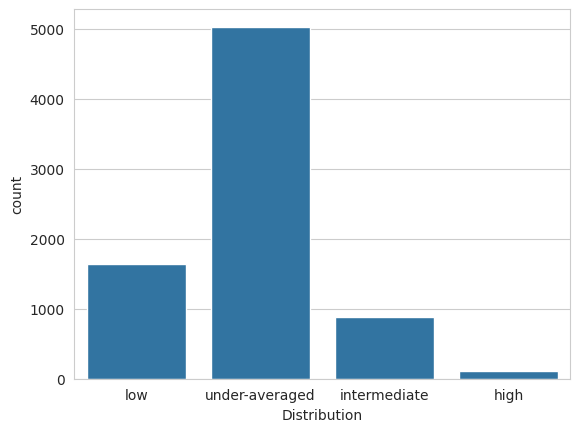

In [ ]:
sns.countplot(data = rfm , x = 'Distribution')

In [ ]:
rfm['RFM_Score'].value_counts().sort_index()

,count
RFM_Score,
3,300
4,523
5,816
6,1386
7,2221
8,1424
9,605
10,273
11,91


## Customer Segmentation by RFM



Segmentation by activity and risk with the definition of each group in the README.

Here is the mathematical definition of each group in this model:

**Low-engagement customer**

For E-Commerce, low-engagement customers are the group of customers that have lost activity for a long period of time (here 180 days) and have never had significant RFM engagement in the past (Lower half population of RFM score).

**Churned**

Churned customers are low-engagement customers that have had significant RFM engagement in the past (Upper half population of RFM score).


**At-risk**

At-risk customers are customers whose recency is under 180 days and higher than two times the span time (First order date - most recent order) divided by all accumulated frequency.

(Recency <= 180) & Recency >= 2 * (Span / Frequency)

**Cannot lose**

Cannot-lose customers are at-risk customers whose RFM score is higher than the 70th percentile of the population.

**Regular customer**

Regular customers are customers that are not in the above groups.


**VIP**

VIP customers are Regular customers whose RFM score is higher than the 85th percentile of all RFM scores.

In [ ]:
rfm['SAR_segment'] = "Regular customer"

In [ ]:
rfm["SAR_segment"].value_counts()

,count
SAR_segment,
Regular customer,7663


In [ ]:
rfm.loc[
    rfm["recency"] > 180,
    "SAR_segment"
] = "Low-engagement customer"

rfm.loc[
    (rfm["recency"] > 180) &
    (rfm["RFM_Score"] > rfm["RFM_Score"].median()),
    "SAR_segment"
] = "churn"

In [ ]:
rfm["SAR_segment"].value_counts()

,count
SAR_segment,
Low-engagement customer,4515
Regular customer,1793
churn,1355


In [ ]:
df["order_date"] = pd.to_datetime(df["order_date"])

temp = df.groupby("customer_id").agg(
    first_order=("order_date", "min"),
    last_order=("order_date", "max"))

rfm = rfm.merge(temp, on="customer_id", how="left")

In [ ]:
rfm["span"] = (rfm["last_order"] - rfm["first_order"]).dt.days


rfm.loc[
    (rfm["recency"] <= 180) &
    (rfm["recency"] > 2 * (rfm["span"] / rfm["frequency"])),
    "SAR_segment"
] = "at risk"

rfm_score_70th_percentile = rfm["RFM_Score"].quantile(0.70)

rfm.loc[
    (rfm["SAR_segment"] == "at risk") &
    (rfm["RFM_Score"] > rfm_score_70th_percentile),
    "SAR_segment"
] = "cannot lose"

In [ ]:
rfm["SAR_segment"].value_counts()

,count
SAR_segment,
Low-engagement customer,4515
Regular customer,1688
churn,1355
at risk,104
cannot lose,1


Now, let's update the SAR_segment column to include the VIP segment.

In [ ]:
import pandas as pd

# Ensure 'df' is loaded if not already in context
# This assumes 'df' is available from previous cells. If 'df' is also undefined, run data loading cells first.
if 'df' not in locals():
    raise NameError("DataFrame 'df' is not defined. Please run the data loading cells first.")

# Re-create rfm DataFrame and its necessary columns (Recency, Frequency, Monetary, RFM_Score, SAR_segment)
# This section is included to handle cases where 'rfm' might not be defined due to out-of-order execution.
# In a typical notebook workflow, these steps would be run in earlier cells.

df['order_date'] = pd.to_datetime(df['order_date'])
snapshot_date = df['order_date'].max()

rfm = df.groupby("customer_id").agg({
    "order_date": lambda x: (snapshot_date - x.max()).days,
    "order_id" : "count",
    "total_amount_usd": "sum"
})
rfm.columns = ["recency", "frequency","monetary"]

recency_scores = [5, 4, 3, 2, 1]
frequency_scores = [1, 2, 3, 4, 5]
monetary_scores = [1, 2, 3, 4, 5]

rfm["recency_scores"] = pd.cut(rfm["recency"], bins = 5 , labels = recency_scores)
rfm["frequency_scores"] = pd.cut(rfm["frequency"], bins = 5 , labels = frequency_scores)
rfm["monetary_scores"] = pd.cut(rfm["monetary"], bins = 5 , labels = monetary_scores)

rfm['frequency_scores'] = rfm['frequency_scores'].astype(int)
rfm['monetary_scores'] = rfm['monetary_scores'].astype(int)
rfm['recency_scores'] = rfm['recency_scores'].astype(int)

rfm['RFM_Score'] = rfm['frequency_scores'] + rfm['monetary_scores'] + rfm['recency_scores']

# Initialize SAR_segment before applying specific rules
rfm['SAR_segment'] = "Regular customer"

# Apply previous segmentation logic as it affects 'Regular customer' before VIP
rfm.loc[
    rfm["recency"] > 180,
    "SAR_segment"
] = "Low-engagement customer"

rfm.loc[
    (rfm["recency"] > 180) &
    (rfm["RFM_Score"] > rfm["RFM_Score"].median()),
    "SAR_segment"
] = "churn"

temp = df.groupby("customer_id").agg(
    first_order=("order_date", "min"),
    last_order=("order_date", "max"))
rfm = rfm.merge(temp, on="customer_id", how="left")
rfm["span"] = (rfm["last_order"] - rfm["first_order"]).dt.days

rfm.loc[
    (rfm["recency"] <= 180) &
    (rfm["recency"] > 2 * (rfm["span"] / rfm["frequency"])),
    "SAR_segment"
] = "at risk"

rfm_score_70th_percentile = rfm["RFM_Score"].quantile(0.70)

rfm.loc[
    (rfm["SAR_segment"] == "at risk") &
    (rfm["RFM_Score"] > rfm_score_70th_percentile),
    "SAR_segment"
] = "cannot lose"

# Now apply the VIP logic
rfm_score_85th_percentile = rfm["RFM_Score"].quantile(0.85)

rfm.loc[
    (rfm["SAR_segment"] == "Regular customer") &
    (rfm["RFM_Score"] > rfm_score_85th_percentile),
    "SAR_segment"
] = "VIP"

In [ ]:
rfm["SAR_segment"].value_counts()

,count
SAR_segment,
Low-engagement customer,4515
churn,1355
Regular customer,1213
VIP,475
at risk,104
cannot lose,1


Show the distribution of each segmentation group.

In [ ]:
for q in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]:
    print(q, rfm["RFM_Score"].quantile(q))

0.1 4.0
0.2 5.0
0.3 6.0
0.4 7.0
0.5 7.0
0.6 7.0
0.7 8.0
0.8 8.0
0.9 9.0


<Axes: xlabel='SAR_segment', ylabel='count'>

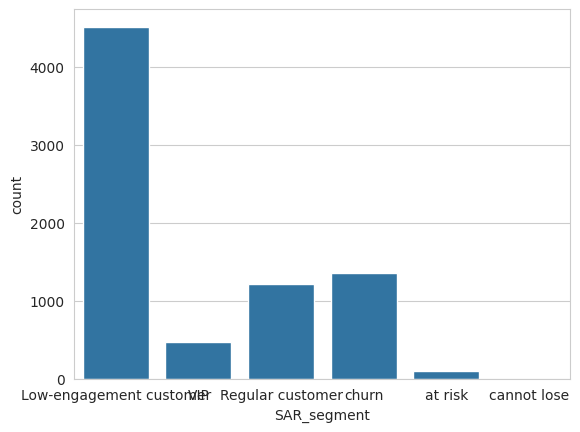

In [ ]:
sns.countplot(data = rfm , x = 'SAR_segment')

In [ ]:
rfm["SAR_segment"].value_counts()

,count
SAR_segment,
Low-engagement customer,4515
churn,1355
Regular customer,1213
VIP,475
at risk,104
cannot lose,1


In [ ]:
distribution_cus = df.merge(
    rfm.reset_index()[["customer_id", "SAR_segment"]],
    on = "customer_id",
    how = "left")

product_dis_cus = distribution_cus.groupby(
    ["SAR_segment", "category"]
)["order_id"].count().reset_index( name = "count")

product_dis_cus["pct"]= product_dis_cus.groupby("SAR_segment")["count"].transform(
    lambda x: x / x.sum()*100
)

product_dis_lost_cus = product_dis_cus.sort_values(
    ["SAR_segment", "pct"],
    ascending=[True, False]
)

product_dis_cus

,SAR_segment,category,count,pct
0,Low-engagement customer,Automotive,343,3.106040
1,Low-engagement customer,Beauty & Personal Care,760,6.882188
2,Low-engagement customer,Books,911,8.249570
3,Low-engagement customer,Clothing & Apparel,1740,15.756588
4,Low-engagement customer,Electronics,1918,17.368469
...,...,...,...,...
71,churn,Office Supplies,218,3.170909
72,churn,Pet Supplies,188,2.734545
73,churn,Sports & Outdoors,458,6.661818
74,churn,Toys & Games,390,5.672727


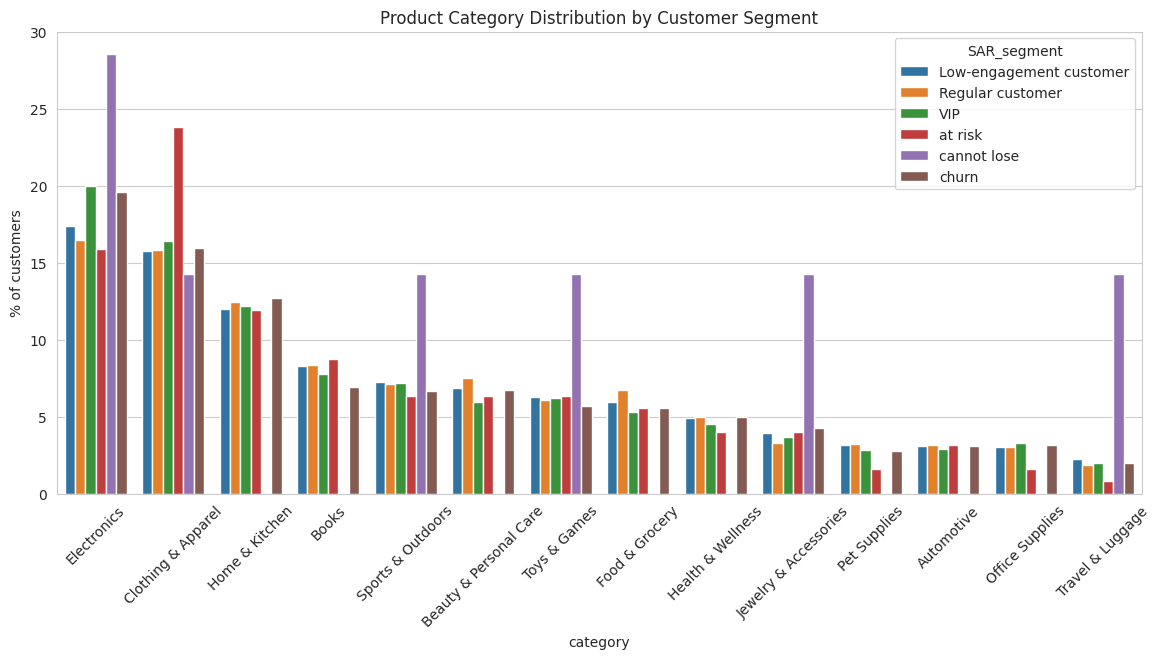

In [ ]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=product_dis_lost_cus,
    x="category",
    y="pct",
    hue="SAR_segment"
)

plt.xticks(rotation=45)
plt.title("Product Category Distribution by Customer Segment")
plt.ylabel("% of customers")
plt.show()

### Group Analysis

We regrouped the original customer segments into two broader categories: Active customers (consisting of Regular Customers and VIP Customers) and Lost Customers (consisting of Low Engagement Customers, Churned Customers, and Cannot Lose Customers). We then compared three pairs of customer groups: Active vs. Lost Customers, Active vs. Low Engagement Customers, and Regular Customers vs. VIP Customers. For each comparison, we analyzed product category distribution, payment method distribution, cohort behavior, and the correlations between key purchasing metrics within each group.

In [ ]:
rfm["comparison_group"] = "Active"
rfm.loc[
    (rfm["SAR_segment"] == "churn") |
    (rfm["SAR_segment"] == "at risk")|
    (rfm["SAR_segment"] == "cannot lose"),
    "comparison_group"
] = "Lost_customers"

rfm.loc[
    (rfm["SAR_segment"] == "Regular customer") |
    (rfm["SAR_segment"] == "VIP"),
    "comparison_group"
] = "Active"

rfm.loc[
    (rfm["SAR_segment"] == "Low-engagement customer"),
    "comparison_group"
] = "Low-engagement customer"




In [ ]:
rfm["comparison_group"].value_counts()

,count
comparison_group,
Low-engagement customer,4515
Active,1688
Lost_customers,1460


In [ ]:
data = df.merge(
    rfm.reset_index()[["customer_id", "comparison_group", "SAR_segment"]],
    on="customer_id",
    how="left"
)

Compared by product distribution.

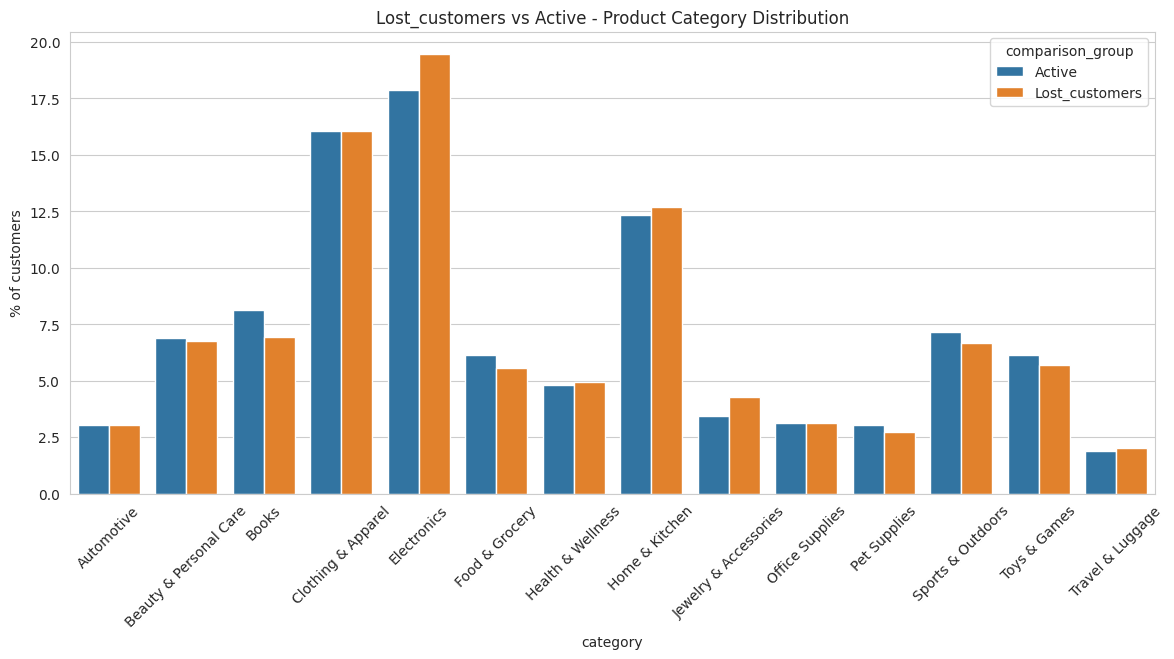

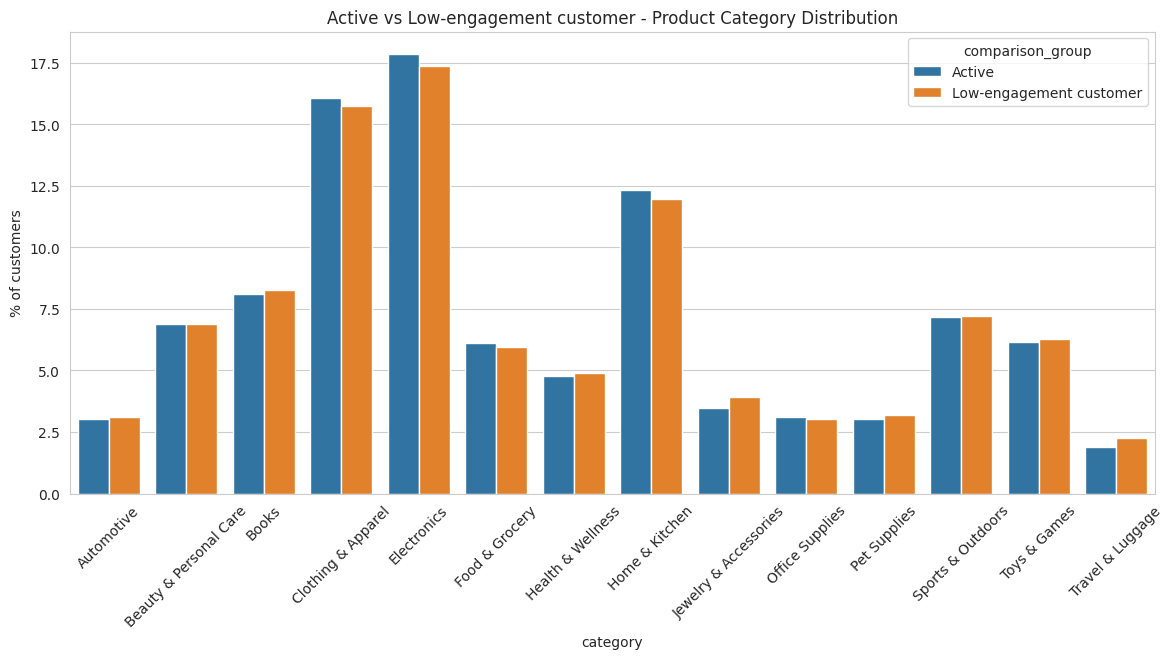

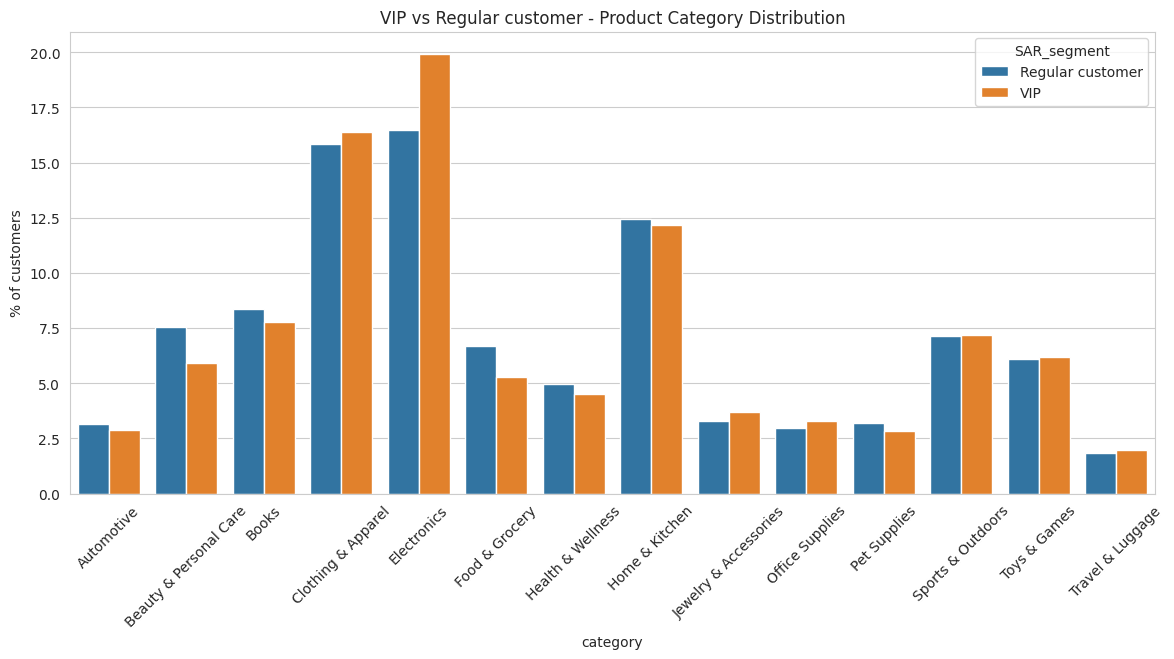

In [ ]:
comparisons = [
    ("Lost_customers", "Active"),
    ("Active", "Low-engagement customer"),
    ("VIP", "Regular customer")
]

for g1, g2 in comparisons:

    if {g1, g2} == {"VIP", "Regular customer"}:
        label_col = "SAR_segment"
    else:
        label_col = "comparison_group"

    subset = data[
        data[label_col].isin([g1, g2])
    ]

    agg = (
        subset
        .groupby([label_col, "category"])
        .size()
        .reset_index(name="count")
    )

    agg["pct"] = agg.groupby(label_col)["count"].transform(
        lambda x: x / x.sum() * 100
    )

    plt.figure(figsize=(14,6))

    sns.barplot(
        data=agg,
        x="category",
        y="pct",
        hue=label_col
    )

    plt.xticks(rotation=45)
    plt.title(f"{g1} vs {g2} - Product Category Distribution")
    plt.ylabel("% of customers")

    plt.show()

Compare by payment methods.

In [ ]:
df["payment_method"].unique().size

7

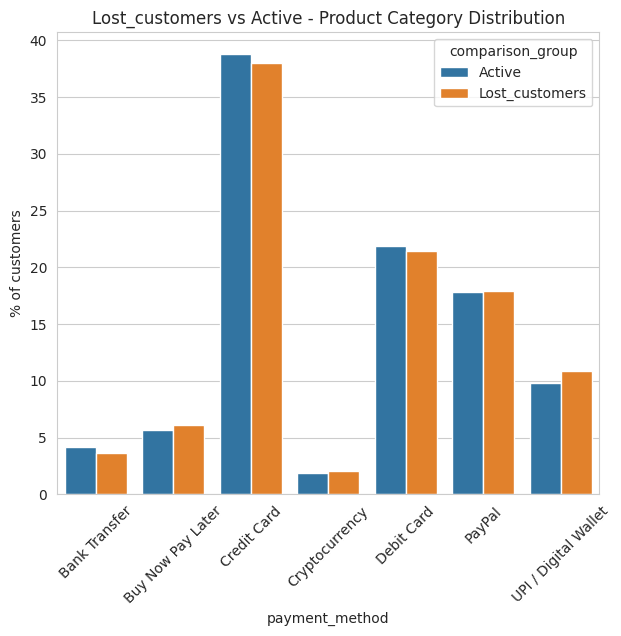

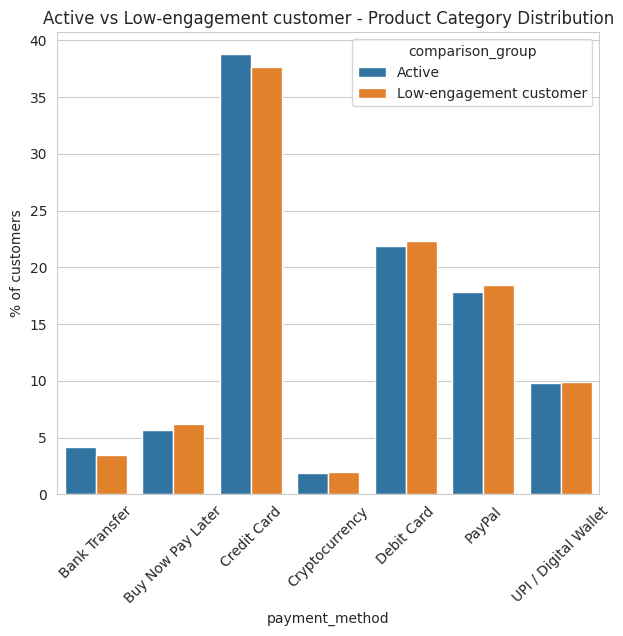

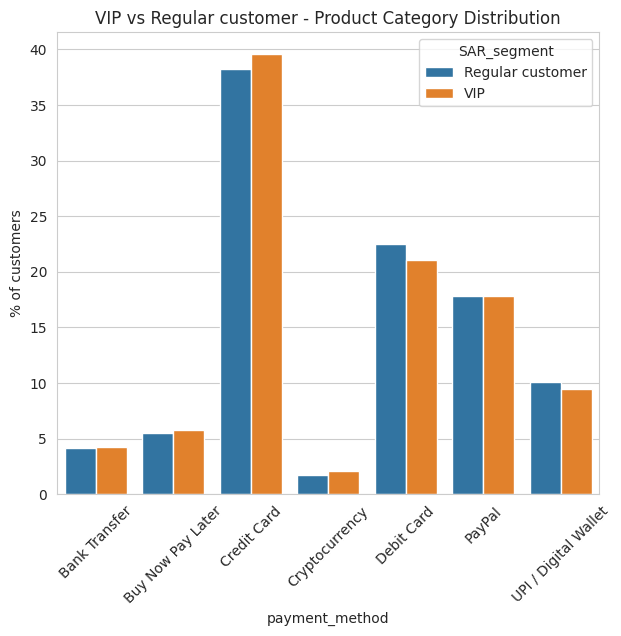

In [ ]:
comparisons = [
    ("Lost_customers", "Active"),
    ("Active", "Low-engagement customer"),
    ("VIP", "Regular customer")
]

for g1, g2 in comparisons:

    if {g1, g2} == {"VIP", "Regular customer"}:
        label_col = "SAR_segment"
    else:
        label_col = "comparison_group"

    subset = data[
        data[label_col].isin([g1, g2])
    ]

    agg = (
        subset
        .groupby([label_col, "payment_method"])
        .size()
        .reset_index(name="count")
    )

    agg["pct"] = agg.groupby(label_col)["count"].transform(
        lambda x: x / x.sum() * 100
    )

    plt.figure(figsize=(7,6))

    sns.barplot(
        data=agg,
        x="payment_method",
        y="pct",
        hue=label_col
    )

    plt.xticks(rotation=45)
    plt.title(f"{g1} vs {g2} - Product Category Distribution")
    plt.ylabel("% of customers")

    plt.show()

Compare by RFM Correlation Matrix.

Comparison 1

Lost Customers (Churn + At Risk) vs. Active Customers (Regular customer + VIP)

>Lost Customers

In [ ]:
Lostcustomers_rfm = rfm[(rfm["SAR_segment"] == 'churn') |
                        (rfm["SAR_segment"] == 'at risk')]
correlation_matrix_Lost_customers = Lostcustomers_rfm[['frequency', 'recency', 'monetary']].corr()
correlation_matrix_Lost_customers

,frequency,recency,monetary
frequency,1.000000,0.370522,0.400009
recency,0.370522,1.000000,0.353543
monetary,0.400009,0.353543,1.000000


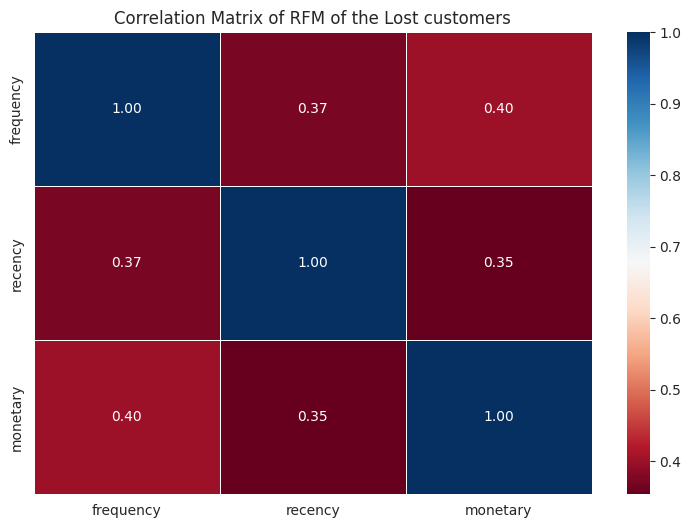

In [ ]:
plt.figure(figsize=(9, 6))
sns.set_style("whitegrid")
sns.heatmap(data=correlation_matrix_Lost_customers, annot=True, cmap="RdBu", cbar=True, fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix of RFM of the Lost customers')
plt.show()

>Active Customers

In [ ]:
Lostcustomers_rfm = rfm[(rfm["SAR_segment"] == 'Regular customer') |
                        (rfm["SAR_segment"] == 'VIP')]
correlation_matrix_active = Lostcustomers_rfm[['frequency', 'recency', 'monetary']].corr()
correlation_matrix_active

,frequency,recency,monetary
frequency,1.00000,-0.036770,0.526800
recency,-0.03677,1.000000,-0.021907
monetary,0.52680,-0.021907,1.000000


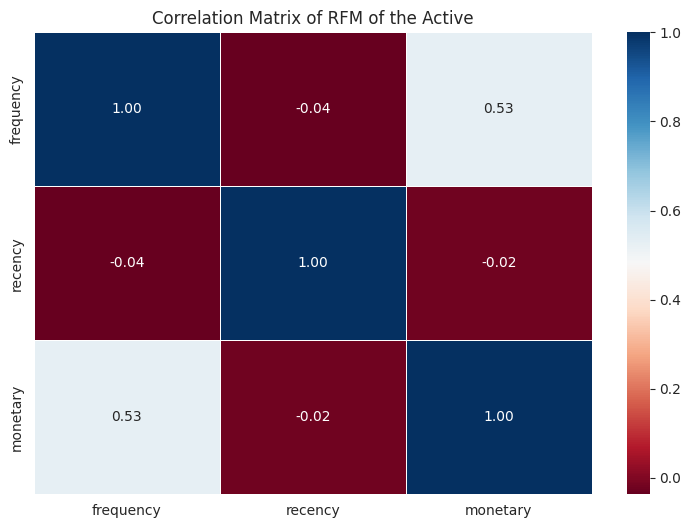

In [ ]:
plt.figure(figsize=(9, 6))
sns.set_style("whitegrid")
sns.heatmap(data=correlation_matrix_active, annot=True, cmap="RdBu", cbar=True, fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix of RFM of the Active')
plt.show()

Comparison 2

Low-engagement Customers vs. Active Customers (Regular customer + VIP)

In [ ]:
Lostcustomers_rfm = rfm[rfm["SAR_segment"] == 'Low-engagement customer']
correlation_matrix_Low_engagementcustomer = Lostcustomers_rfm[['frequency', 'recency', 'monetary']].corr()
correlation_matrix_Low_engagementcustomer

,frequency,recency,monetary
frequency,1.000000,-0.264399,0.507441
recency,-0.264399,1.000000,-0.106613
monetary,0.507441,-0.106613,1.000000


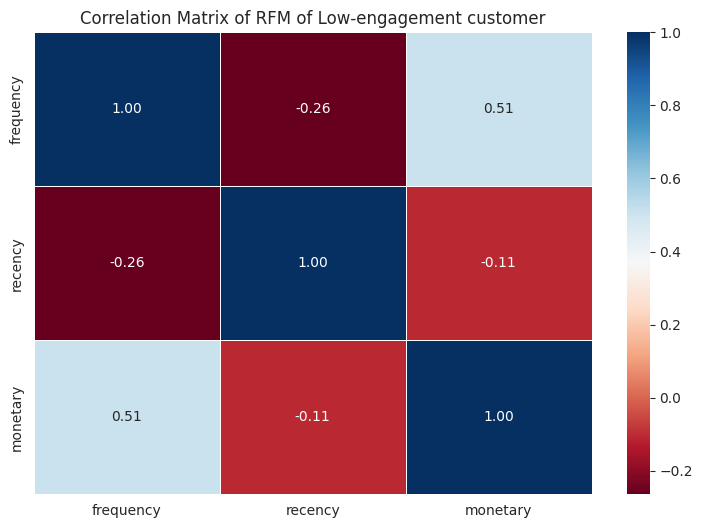

In [ ]:
plt.figure(figsize=(9, 6))
sns.set_style("whitegrid")
sns.heatmap(data=correlation_matrix_Low_engagementcustomer, annot=True, cmap="RdBu", cbar=True, fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix of RFM of Low-engagement customer')
plt.show()

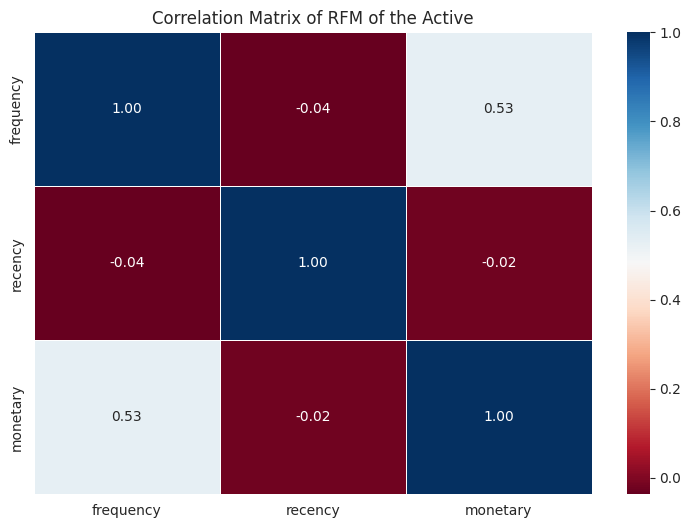

In [ ]:
plt.figure(figsize=(9, 6))
sns.set_style("whitegrid")
sns.heatmap(data=correlation_matrix_active, annot=True, cmap="RdBu", cbar=True, fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix of RFM of the Active')
plt.show()

Comparison 3

VIP vs. Regular Customers

>VIP Customers

In [ ]:
Lostcustomers_rfm = rfm[rfm["SAR_segment"] == 'VIP']
correlation_matrix_VIP = Lostcustomers_rfm[['frequency', 'recency', 'monetary']].corr()
correlation_matrix_VIP

,frequency,recency,monetary
frequency,1.000000,0.009291,-0.188450
recency,0.009291,1.000000,0.030321
monetary,-0.188450,0.030321,1.000000


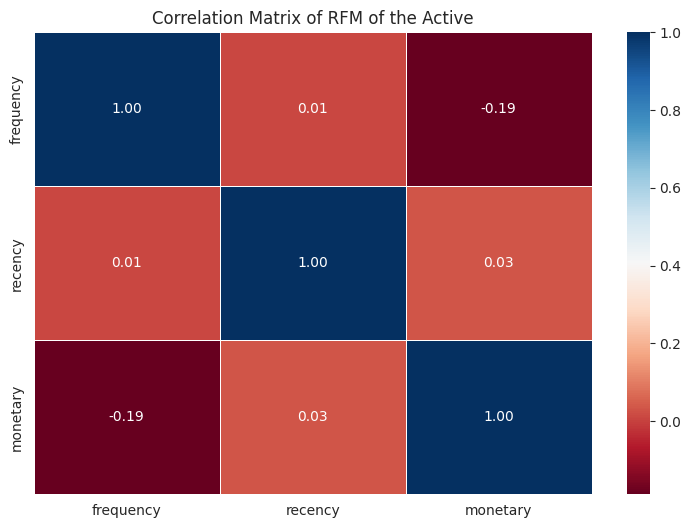

In [ ]:
plt.figure(figsize=(9, 6))
sns.set_style("whitegrid")
sns.heatmap(data=correlation_matrix_VIP, annot=True, cmap="RdBu", cbar=True, fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix of RFM of the Active')
plt.show()

>Regular Customers

In [ ]:
Lostcustomers_rfm = rfm[rfm["SAR_segment"] == 'Regular customer']
correlation_matrix_Regular_customer = Lostcustomers_rfm[['frequency', 'recency', 'monetary']].corr()
correlation_matrix_Regular_customer

,frequency,recency,monetary
frequency,1.000000,-0.005023,0.349882
recency,-0.005023,1.000000,0.009568
monetary,0.349882,0.009568,1.000000


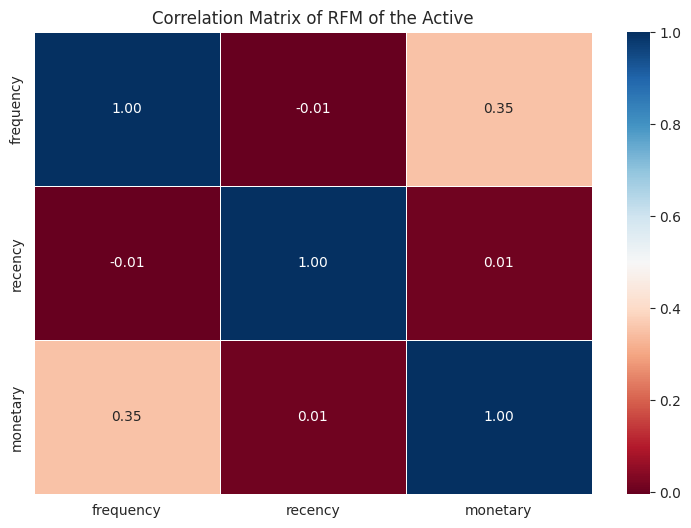

In [ ]:
plt.figure(figsize=(9, 6))
sns.set_style("whitegrid")
sns.heatmap(data=correlation_matrix_Regular_customer, annot=True, cmap="RdBu", cbar=True, fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix of RFM of the Active')
plt.show()

In [ ]:
rfm["comparison_group"].unique()

array(['Low-engagement customer', 'Active', 'Lost_customers'],
      dtype=object)

## Hypothesis Testing

As discussed earlier in the README, we identified several candidate hypotheses that may explain customer churn behavior. These hypotheses include the price of products purchased, the effect of discounts, the influence of shipping fees, the impact of order waiting time, and users' screen time session duration. To evaluate these hypotheses, we performed independent two-sample t-tests and used the corresponding p-values to determine whether there were statistically significant differences between the Active Customer group and the Lost Customer group.

In [ ]:
hypo = rfm[rfm["comparison_group"].isin(["Active", 'Lost_customers'])].copy()

Price Sensitivity Test

In [ ]:
hypo_pur = df.merge(
    hypo.reset_index()[["customer_id", "comparison_group", "SAR_segment"]],
    on="customer_id",
    how="left"
)

active_pur = hypo_pur.loc[
    hypo_pur["comparison_group"] == "Active",
    "total_amount_usd"]

lost_pur = hypo_pur.loc[
    hypo_pur["comparison_group"] == "Lost_customers",
    "total_amount_usd"]

t_stat_pur, p_value_pur = ttest_ind(
    active_pur,
    lost_pur,
    equal_var=False
)

print(t_stat_pur)
print(p_value_pur)


-6.05927690173568
1.4037237264636708e-09


In [ ]:
print(active_pur.mean())
print(lost_pur.mean())

124.9657850050367
141.3628410388128


<Axes: xlabel='comparison_group', ylabel='total_amount_usd'>

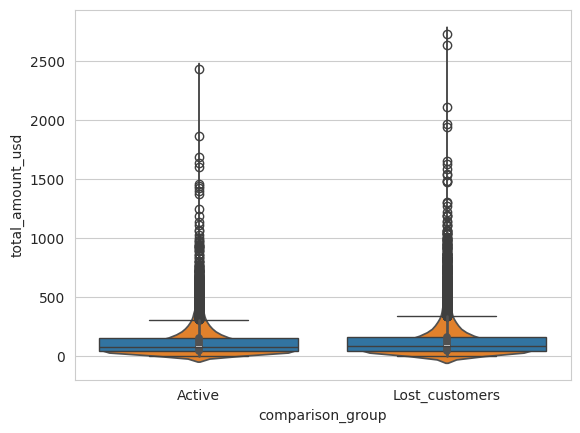

In [ ]:
sns.boxplot(
    data=hypo_pur,
    x="comparison_group",
    y="total_amount_usd"
)

sns.violinplot(
    data=hypo_pur,
    x="comparison_group",
    y="total_amount_usd"
)

Result: Statistically significant difference.

Test the influence of discount percentage.

In [ ]:
hypo_disc_pct = df.merge(
    hypo.reset_index()[["customer_id", "comparison_group", "SAR_segment"]],
    on="customer_id",
    how="left"
)

active_disc_pct = hypo_disc_pct.loc[
    hypo_disc_pct["comparison_group"] == "Active",
    "discount_pct"]

lost_disc_pct = hypo_disc_pct.loc[
    hypo_disc_pct["comparison_group"] == "Lost_customers",
    "discount_pct"]

t_stat_disc_pct, p_value_disc_pct = ttest_ind(
    active_disc_pct,
    lost_disc_pct,
    equal_var=False
)

print(t_stat_disc_pct)
print(p_value_disc_pct)

0.9360572630409159
0.349259908095084


<Axes: xlabel='comparison_group', ylabel='discount_pct'>

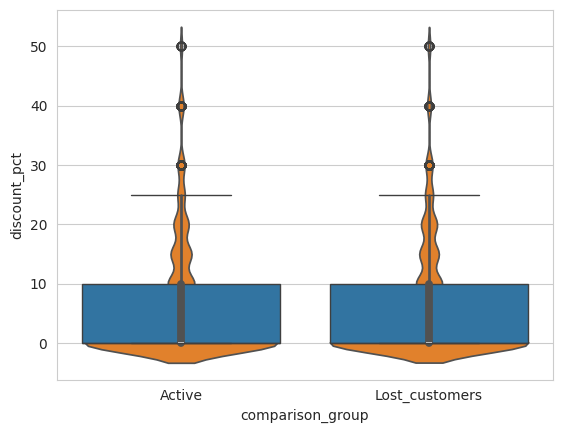

In [ ]:
sns.boxplot(
    data=hypo_disc_pct,
    x="comparison_group",
    y="discount_pct"
)

sns.violinplot(
    data=hypo_disc_pct,
    x="comparison_group",
    y="discount_pct"
)

Result: No statistical significance.

Test the influence of discount amount.

In [ ]:
hypo_disc = df.merge(
    hypo.reset_index()[["customer_id", "comparison_group", "SAR_segment"]],
    on="customer_id",
    how="left"
)

active_pur = hypo_pur.loc[
    hypo_pur["comparison_group"] == "Active",
    "discount_amount_usd"]

lost_pur = hypo_pur.loc[
    hypo_pur["comparison_group"] == "Lost_customers",
    "discount_amount_usd"]

t_stat_pur, p_value_pur = ttest_ind(
    active_pur,
    lost_pur,
    equal_var=False
)

print(t_stat_pur)
print(p_value_pur)


-1.9076915594477581
0.056452017435575375


Result: No clear statistical significance.

Test the influence of shipping fee amount.

In [ ]:
hypo_ship = df.merge(
    hypo.reset_index()[["customer_id", "comparison_group", "SAR_segment"]],
    on="customer_id",
    how="left"
)

active_ship = hypo_ship.loc[
    hypo_ship["comparison_group"] == "Active",
    "shipping_fee_usd"]

lost_ship = hypo_ship.loc[
    hypo_ship["comparison_group"] == "Lost_customers",
    "shipping_fee_usd"]

t_stat_ship, p_value_ship = ttest_ind(
    active_ship,
    lost_ship,
    equal_var=False
)

print(t_stat_ship)
print(p_value_ship)

0.4108624826116025
0.6811796824825875


<Axes: xlabel='comparison_group', ylabel='shipping_fee_usd'>

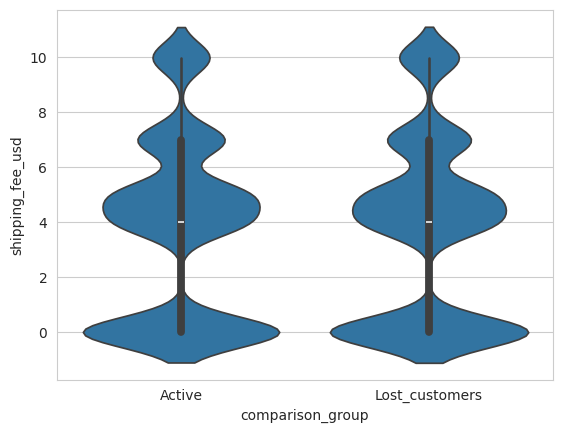

In [ ]:
sns.violinplot(
    data=hypo_disc_pct,
    x="comparison_group",
    y="shipping_fee_usd"
)


Result: No statistical significance.

Test the influence of waiting time after order.

In [ ]:
df["waiting time"] = (df["delivery_date"] - df["order_date"]).dt.days

hypo_wait = df.merge(
    hypo.reset_index()[["customer_id", "comparison_group", "SAR_segment"]],
    on="customer_id",
    how="left"
)

active_wait = hypo_wait.loc[
    hypo_wait["comparison_group"] == "Active",
    "waiting time"]

lost_wait = hypo_wait.loc[
    hypo_wait["comparison_group"] == "Lost_customers",
    "waiting time"]

t_stat_wait, p_value_wait = ttest_ind(
    active_wait,
    lost_wait,
    equal_var=False
)

print(t_stat_wait)
print(p_value_wait)

1.1662157068730468
0.2435471980328432


Result: No statistical significance.

Test the influence of screen session time amount.

In [ ]:
hypo_session = df.merge(
    hypo.reset_index()[["customer_id", "comparison_group", "SAR_segment"]],
    on="customer_id",
    how="left"
)

active_session = hypo_session.loc[
    hypo_session["comparison_group"] == "Active",
    "session_duration_minutes"]

lost_session = hypo_session.loc[
    hypo_session["comparison_group"] == "Lost_customers",
    "session_duration_minutes"]

t_stat_session, p_value_session = ttest_ind(
    active_session,
    lost_session,
    equal_var=False
)

print(t_stat_session)
print(p_value_session)

-0.5163336295750895
0.6056295970644048


Result: No statistical significance.

Test correlation of the amount of pages viewed before purchase.

In [ ]:
hypo_pages = df.merge(
    hypo.reset_index()[["customer_id", "comparison_group", "SAR_segment"]],
    on="customer_id",
    how="left"
)

active_pages = hypo_pages.loc[
    hypo_pages["comparison_group"] == "Active",
    "pages_viewed_before_purchase"]

lost_pages = hypo_pages.loc[
    hypo_pages["comparison_group"] == "Lost_customers",
    "pages_viewed_before_purchase"]

t_stat_pages, p_value_pages = ttest_ind(
    active_pages,
    lost_pages,
    equal_var=False
)

print(t_stat_pages)
print(p_value_pages)

0.13697784179431233
0.8910502858495175


Result: No statistical significance.

## Red Flag Product Identification

The objective of this section is to identify products that are disproportionately consumed by different customer groups. Products are classified into three categories:

- Churn-associated products: Products whose consumption by Lost Customers falls within the top 10% (90th percentile or above).
- Retention-friendly products: Products whose consumption by Active Customers falls within the top 10%.
- Retention-neutral products: Products that do not belong to either of the above categories.

This classification helps identify products that are potentially associated with customer churn or customer retention.

In [ ]:
product_st = df.merge(
    hypo.reset_index()[["customer_id", "comparison_group", "SAR_segment"]],
    on="customer_id",
    how="left"
)

tmn = product_st[[
    "product_name",
    "customer_id",
    "comparison_group",
    "total_amount_usd"
]].copy()

data_unique = tmn.drop_duplicates(
    subset=["product_name", "customer_id"]
)

segment_table = data_unique.groupby(
    ["product_name", "comparison_group"]
)["customer_id"].nunique().reset_index(name="n_customers")

segment_pivot = segment_table.pivot(
    index="product_name",
    columns="comparison_group",
    values="n_customers"
).fillna(0)

segment_pivot["total_customers"] = segment_pivot.sum(axis=1)

segment_pivot["total_revenue"] = tmn.groupby("product_name")["total_amount_usd"].sum()

segment_pivot["lost_share"] = (
    segment_pivot.get("Lost_customers", 0) /
    segment_pivot["total_customers"].replace(0, 1)
)

segment_pivot["active_share"] = (
    segment_pivot.get("Active", 0) /
    segment_pivot["total_customers"].replace(0, 1)
)

segment_pivot = segment_pivot[segment_pivot["total_customers"] >= 30].copy()

top_cut = segment_pivot["lost_share"].quantile(0.90)
bottom_cut = segment_pivot["lost_share"].quantile(0.10)

segment_pivot["product_flag"] = "neutral"

segment_pivot.loc[
    segment_pivot["lost_share"] >= top_cut,
    "product_flag"
] = "churn_associated"

segment_pivot.loc[
    segment_pivot["lost_share"] <= bottom_cut,
    "product_flag"
] = "retention_friendly"

result_flag = segment_pivot.sort_values(
    by="total_revenue",
    ascending=False
)

List of all 14 "Red Flag" or "Churn-Associated" products.

In [ ]:
result_flag[result_flag["product_flag"]=="churn_associated"]

comparison_group,Active,Lost_customers,total_customers,total_revenue,lost_share,active_share,product_flag
product_name,,,,,,,
Smart Watch Series 5,107,147,254,116859.12,0.578740,0.421260,churn_associated
Ring Set 5pc,21,35,56,17722.40,0.625000,0.375000,churn_associated
Stud Earrings Gold,24,32,56,16303.93,0.571429,0.428571,churn_associated
Tennis Racket,35,49,84,16282.64,0.583333,0.416667,churn_associated
Sterling Silver Necklace,23,35,58,13699.47,0.603448,0.396552,churn_associated
Ergonomic Chair,16,24,40,13362.44,0.600000,0.400000,churn_associated
Minimalist Watch,24,32,56,12930.23,0.571429,0.428571,churn_associated
Remote Control Car,34,47,81,12429.18,0.580247,0.419753,churn_associated
Leather Wallet,18,28,46,10861.93,0.608696,0.391304,churn_associated
